# Exp8.0.5 — Frozen backbone phase readout

Aggregation-only notebook. It reads finalized CSV/JSON artifacts and does **not** train or refit any model.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
while repo != repo.parent and not (repo / 'pyproject.toml').exists():
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_8_0_5_frozen_backbone_phase_readout' / 'frozen_backbone_phase_readout_v1'
manifest = json.loads((base / 'manifest.json').read_text())
method_summary = pd.read_csv(base / 'method_summary.csv')
paired_summary = pd.read_csv(base / 'paired_delta_summary.csv')
branch_summary = pd.read_csv(base / 'branch_ablation_summary.csv')
phase_summary = pd.read_csv(base / 'phase_shift_summary.csv')
history = pd.read_csv(base / 'history_runs.csv')
manifest


{'architecture': '234x234',
 'architecture_shifts': [[2, 3, 4], [2, 3, 4]],
 'backbone_frozen': True,
 'counts': {'methods': 4, 'parallel_runs': 12, 'seeds': 3},
 'diagnostics': ['full/L1-only/L2-only test BA and branch removal drops',
  'true-phase global circular-shift sweep over every phase bin'],
 'experiment_id': 'experiment_8_0_5_frozen_backbone_phase_readout',
 'methods': ['l2_whole',
  'l1_l2_timeshared',
  'l1_fixed250_l2_whole_true_phase',
  'l1_fixed250_l2_whole_destroyed_phase'],
 'phase_destroyed_control': 'sample-specific deterministic non-zero cyclic phase offset; same Bx128 L1 feature bank and same head dimensionality as true phase',
 'phase_pair_initialization': 'true-phase and destroyed-phase heads use the exact same initialization seed at each backbone seed',
 'primary_comparison': 'l1_fixed250_l2_whole_true_phase - l1_fixed250_l2_whole_destroyed_phase',
 'protocol_version': 'frozen_backbone_phase_readout_v1',
 'seeds': [11, 23, 37],
 'source_backbone_method': 'l1_l2

## Native frozen-readout comparison


,method,test_ba_mean,test_ba_std,val_ba_mean,best_epoch_mean,parameter_count_mean
2,l1_fixed250_l2_whole_true_phase,0.607935,0.035136,0.610780,83.333333,26112.0
1,l1_l2_timeshared,0.564175,0.027582,0.579916,98.000000,3072.0
0,l2_whole,0.555713,0.028701,0.577457,76.000000,1536.0
3,l1_fixed250_l2_whole_destroyed_phase,0.534638,0.010427,0.553295,63.333333,26112.0


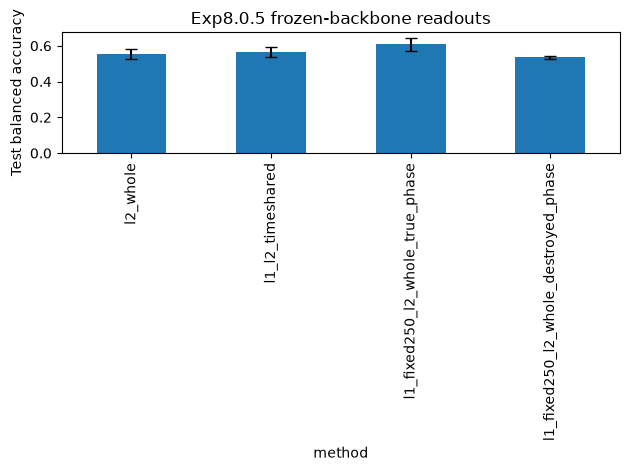

In [2]:
cols = ['method', 'test_ba_mean', 'test_ba_std', 'val_ba_mean', 'best_epoch_mean', 'parameter_count_mean']
display(method_summary[cols].sort_values('test_ba_mean', ascending=False))

plot_df = method_summary.set_index('method')
ax = plot_df['test_ba_mean'].plot(kind='bar', yerr=plot_df['test_ba_std'], capsize=4)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Exp8.0.5 frozen-backbone readouts')
plt.tight_layout()
plt.show()


## Paired seed deltas


In [3]:
display(paired_summary)
primary = paired_summary[paired_summary['comparison'] == 'true_phase_vs_destroyed_phase']
primary


,comparison,test_ba_delta_mean,test_ba_delta_std,val_ba_delta_mean,val_ba_delta_std
0,true_phase_vs_destroyed_phase,0.073297,0.024988,0.057486,0.049022
1,true_phase_vs_timeshared,0.043761,0.023359,0.030864,0.022618
2,timeshared_vs_l2,0.008461,0.002197,0.002459,0.020362


,comparison,test_ba_delta_mean,test_ba_delta_std,val_ba_delta_mean,val_ba_delta_std
0,true_phase_vs_destroyed_phase,0.073297,0.024988,0.057486,0.049022


## L1/L2 branch contribution diagnostics


,method,full_ba_mean,l1_only_ba_mean,l2_only_ba_mean,l1_removal_drop_mean,l2_removal_drop_mean,full_equals_branch_sum_max_error_mean
0,l2_whole,0.555713,NaN,0.555713,0.000000,NaN,0.000000e+00
3,l1_l2_timeshared,0.564175,0.203179,0.539364,0.024811,0.360996,2.940496e-06
6,l1_fixed250_l2_whole_true_phase,0.607935,0.317116,0.547796,0.060139,0.290820,0.000000e+00
9,l1_fixed250_l2_whole_destroyed_phase,0.534638,0.168254,0.551103,-0.016465,0.366385,9.536743e-07


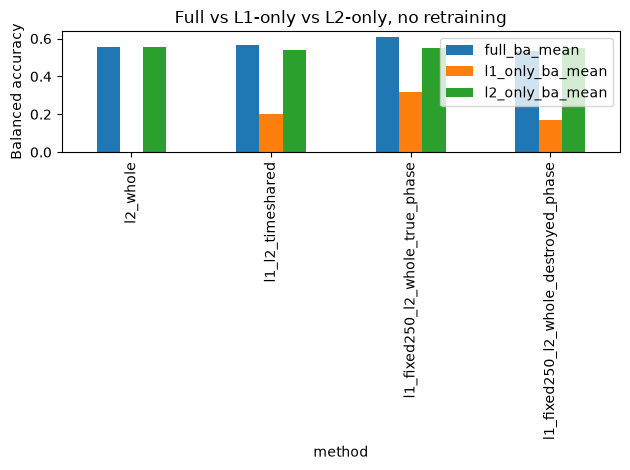

In [4]:
test_branch = branch_summary[branch_summary['split'] == 'test'].copy()
cols = ['method', 'full_ba_mean', 'l1_only_ba_mean', 'l2_only_ba_mean', 'l1_removal_drop_mean', 'l2_removal_drop_mean', 'full_equals_branch_sum_max_error_mean']
display(test_branch[cols])

branch_plot = test_branch.set_index('method')[['full_ba_mean', 'l1_only_ba_mean', 'l2_only_ba_mean']]
ax = branch_plot.plot(kind='bar')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Full vs L1-only vs L2-only, no retraining')
plt.tight_layout()
plt.show()


## True-phase circular-shift diagnostic

`shift_bins=0` is the correctly aligned phase assignment. All other points keep the trained head fixed and deliberately misalign L1 phase blocks.


,shift_bins,shift_ms,test_ba_mean,test_ba_std
0,0.0,0.0,0.607935,0.035136
1,1.0,250.0,0.597620,0.019941
2,2.0,500.0,0.547267,0.034309
3,3.0,750.0,0.429723,0.015687
4,4.0,1000.0,0.370055,0.010313
5,5.0,1250.0,0.369452,0.020108
6,6.0,1500.0,0.359396,0.010594
7,7.0,1750.0,0.364641,0.014444
8,8.0,2000.0,0.412382,0.027522
9,9.0,2250.0,0.454244,0.010119


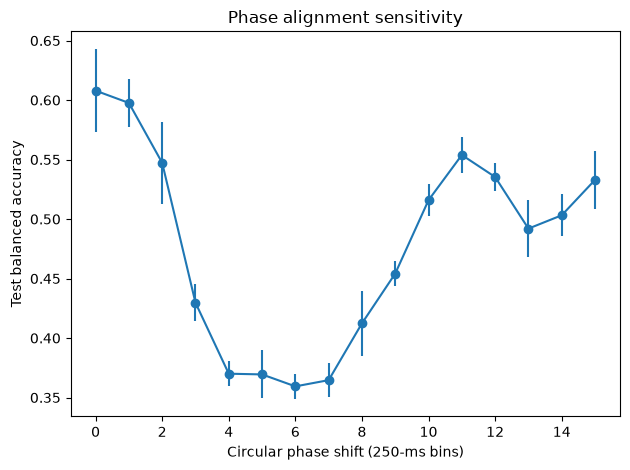

In [5]:
display(phase_summary[['shift_bins', 'shift_ms', 'test_ba_mean', 'test_ba_std']])
curve = phase_summary.sort_values('shift_bins')
plt.errorbar(curve['shift_bins'], curve['test_ba_mean'], yerr=curve['test_ba_std'], marker='o')
plt.xlabel('Circular phase shift (250-ms bins)')
plt.ylabel('Test balanced accuracy')
plt.title('Phase alignment sensitivity')
plt.tight_layout()
plt.show()


## Method-level training curves


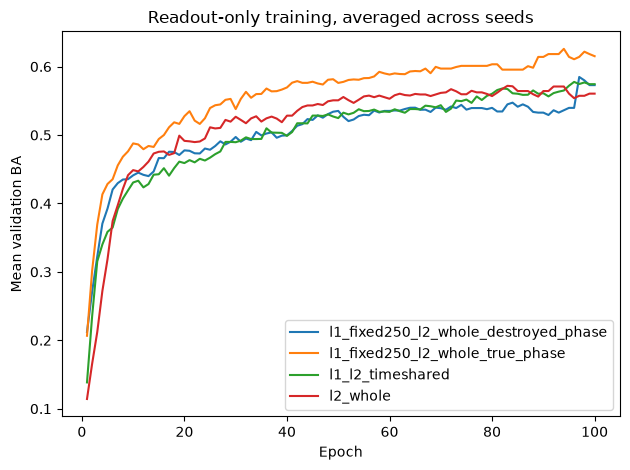

In [6]:
mean_history = history.groupby(['method', 'epoch'], as_index=False)[['train_ba', 'val_ba', 'train_loss', 'val_loss']].mean()
for method, frame in mean_history.groupby('method'):
    plt.plot(frame['epoch'], frame['val_ba'], label=method)
plt.xlabel('Epoch')
plt.ylabel('Mean validation BA')
plt.title('Readout-only training, averaged across seeds')
plt.legend()
plt.tight_layout()
plt.show()
